In [1]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/main/data/reddit.csv"
)

In [9]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [10]:
df.shape

(37249, 2)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [12]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [13]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [14]:
df[df['clean_comment'].isna()]['category'].value_counts()

,count
category,
0,100


In [15]:
df.dropna(inplace=True)

In [16]:
df.duplicated().sum()

np.int64(350)

In [17]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df[(df['clean_comment'].str.strip()=='')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [21]:
df[~(df['clean_comment'].str.strip()=='')]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [22]:
# To lowercase
df['clean_comment']=df['clean_comment'].str.lower()

# Verify
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [23]:
df[df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [24]:
# Identify comments containing URL
url_pattern=r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls=df[df['clean_comment'].str.contains(url_pattern,regex=True)]

# Display the comments containing URLs
comments_with_urls.head()

,clean_comment,category


In [25]:
# Remove new line characters from the 'clean_comment' column
df['clean_comment']=df['clean_comment'].str.replace('\n',' ',regex=True)

# Verify
comments_with_newline_remaining=df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


**understanding your dataset before building a model : EDA**

<Axes: xlabel='category', ylabel='count'>

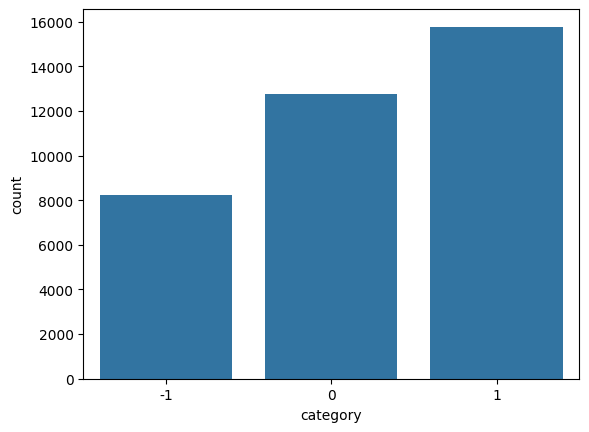

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# distribution of classes

sns.countplot(data=df,x='category')

In [27]:
# frequency distribution of sentiments

df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,42.86
0,34.72
-1,22.42


In [28]:
df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))

In [29]:
df.sample(5)

,clean_comment,category,word_count
10660,surprised maximum replies are yes,1,5
30415,says the guy who said want conress mukt bharat,0,9
28138,wosh haha libar trol,1,4
11333,bhai rehne such cringe,0,4
10743,makes chai serves chai profit,0,5


In [30]:
df['word_count'].describe()

,word_count
count,36799.000000
mean,29.662627
std,56.787371
min,0.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


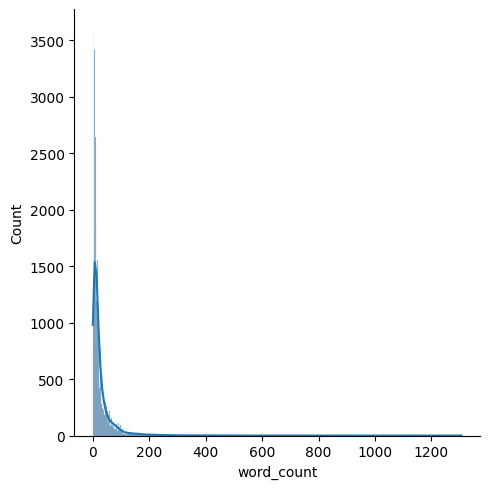

In [31]:
sns.displot(df['word_count'],kde=True)

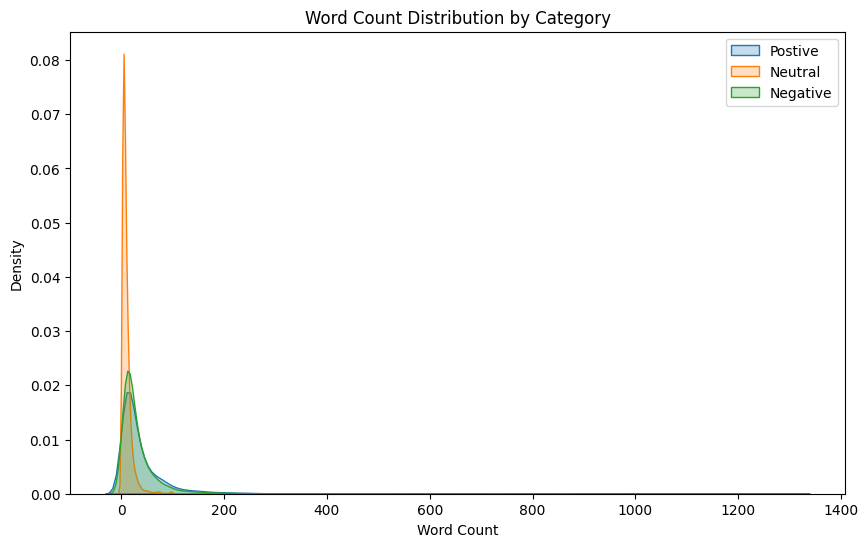

In [33]:
# Create the figure
plt.figure(figsize=(10,6))

# Plot KDE for category 1
sns.kdeplot(df[df['category']==1]['word_count'],label='Postive',fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category']==0]['word_count'],label='Neutral',fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category']==-1]['word_count'],label='Negative',fill=True)

# Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

plt.legend()
plt.show()

**Postive comments(category 1)**: These tend to have a wider spread in word count, indicating that longer comments are more common in postive sentiments.

**Neural comments (category 0)**: The distribution shows a relatively lower frequency and is more concentrated around shorter comments compared to positive or negative ones.

**Negative comments (category -1)**: These comments have a distribution some what similar to positive comments but with a smaller proportion of longer comments

<Axes: ylabel='word_count'>

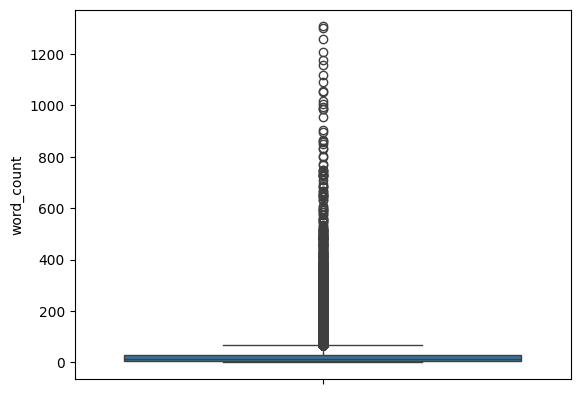

In [35]:
sns.boxplot(df['word_count'])

**Most texts are short**: The box (middle part) is very close to the bottom (near 0–50 words roughly).This means most comments have a small number of words.

**Strong right-skewed distribution**: There are many points going far upward (outliers), reaching 1000+ words.This means a small number of texts are extremely long, while most are short.

**Many outliers**: The dots above the box are outliers.So your dataset contains:
a few very long texts (200 → 1300 words)
but they are rare compared to normal ones

**Median is low**: The line inside the box (median) is low. Half of your data is below a small word count → again confirms most texts are short.

**Highly imbalanced in length (many short texts + few very long ones)**

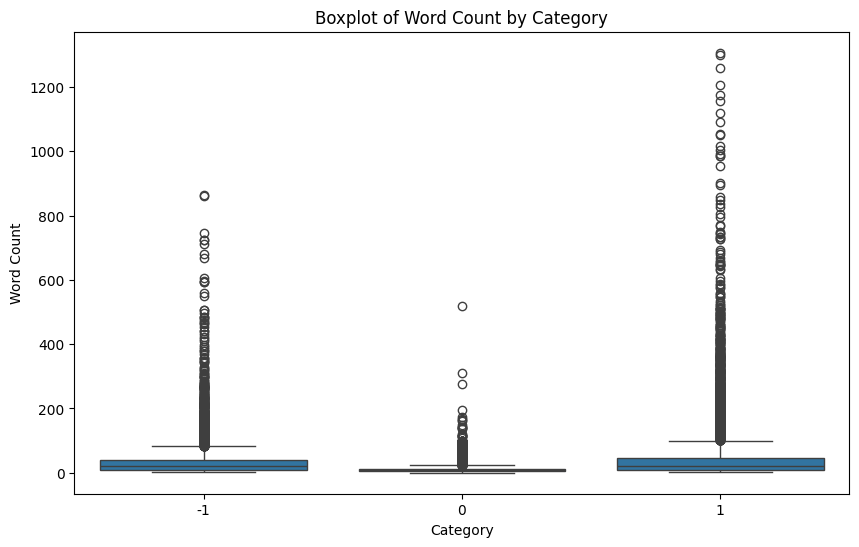

In [36]:
# Create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='category',y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

**Postive comments (category 1)**: The median word count is relatively high and there are several outliers with longer comments, indicating that postive comments tend to be more verbose

**Neural comments (category 0)**:The median word count is the lowest,with a tighter interquartile range(IQR),suggesting that neutral comments are generally shorter

**Negative comments (category -1)**:The word count distribution is similar to positive comments but with a slightly lower median and fewer extreme outliers

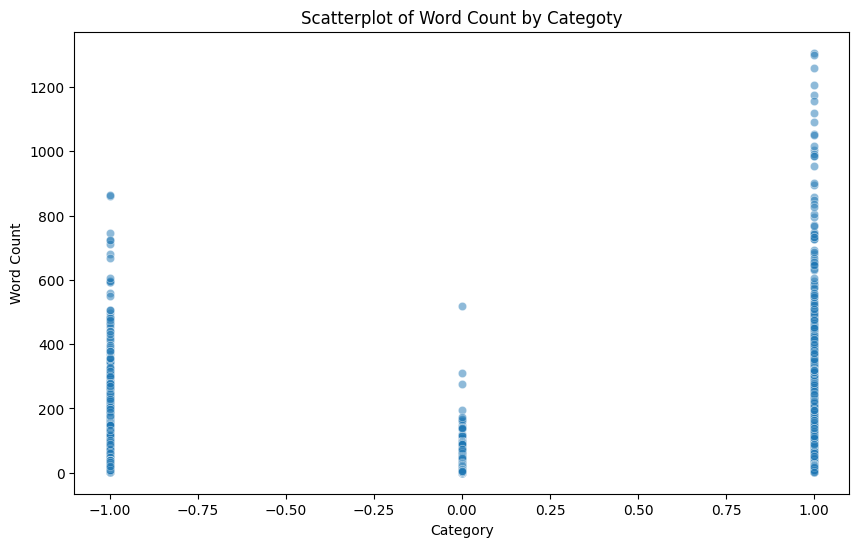

In [38]:
# Create a scatterplot between 'category' and 'wordcount'
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='category',y='word_count',alpha=0.5)
plt.title('Scatterplot of Word Count by Categoty')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

**Used to check**:

-See how word length varies across categories

-Detect patterns or differences

-Identify imbalance or behavior

<Axes: xlabel='category', ylabel='word_count'>

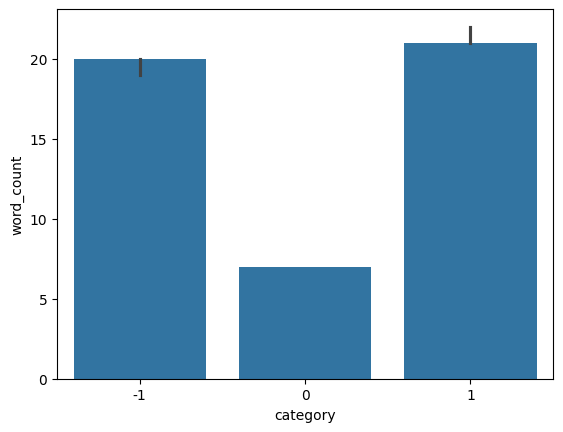

In [39]:
# median word counts among sentiments

sns.barplot(df,x="category",y='word_count',estimator='median')

In [41]:
!pip install nltk

In [43]:
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
import nltk
nltk.download('stopwords')

# Define the list of English stopwords
stop_words=set(stopwords.words('english'))

# Create a new column 'num_stop_words' by counting the number of stopwords in each comment
df['num_stop_words']=df['clean_comment'].apply(lambda x:len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [44]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
2510,that all indian women only want falsely accuse...,-1,29,11
11858,hwndu stream they had build wall and divide th...,1,11,4
33704,dawg why the fuck are you turning into racial ...,-1,10,5
2098,the president going mai mai like sheep wish wo...,0,23,6
28000,that newspaper hope you didn have pay for,0,8,5


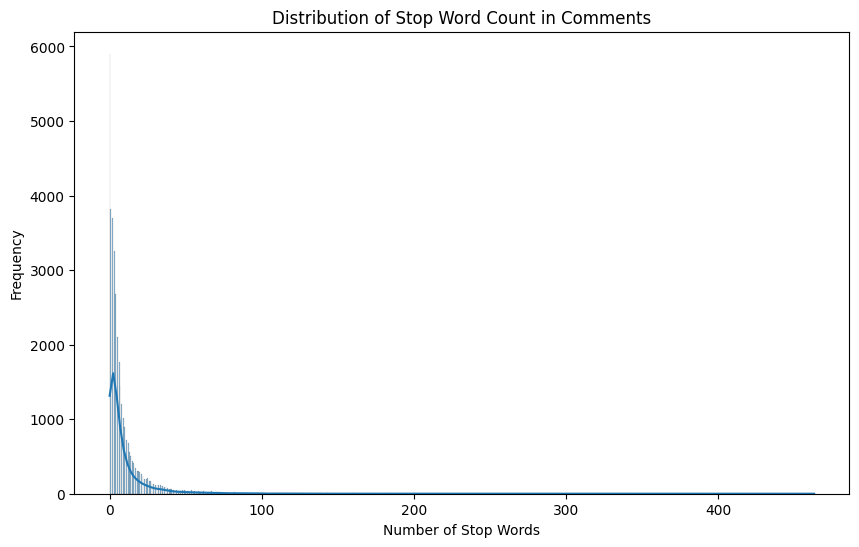

In [45]:
# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10,6))
sns.histplot(df["num_stop_words"],kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

**Main observation**:

-The distribution is highly skewed to the right

-The majority of comments contain very few stop words (around 0 to ~20)

-Very few comments contain a large number of stop words

-There is a long tail extending up to ~400+

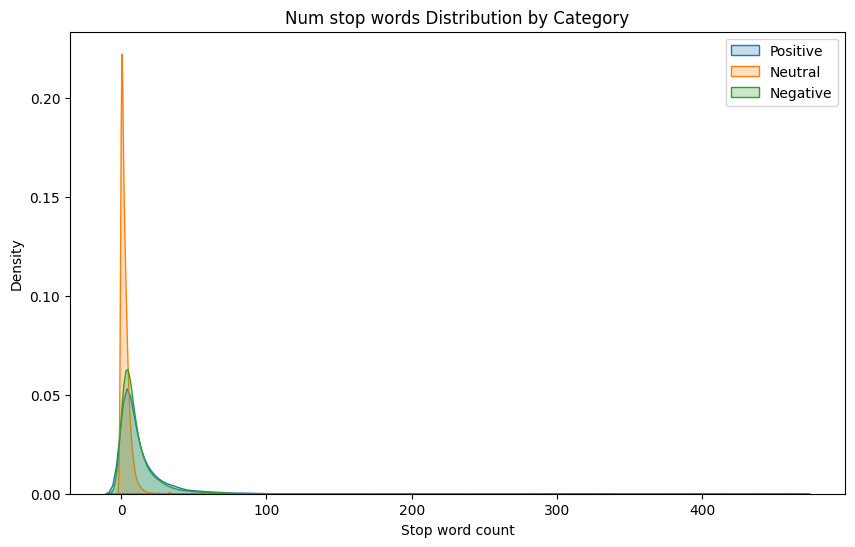

In [46]:
# Create the figure and axes
plt.figure(figsize=(10,6))

# Plot KDE for category 1
sns.kdeplot(df[df['category']==1]['num_stop_words'],label='Positive',fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category']==0]['num_stop_words'],label='Neutral',fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category']==-1]['num_stop_words'],label='Negative',fill=True)

# Add title and labels
plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

# Add a legend
plt.legend()
plt.show()

**Conclusion**

-Neutral comments are generally short and simple

-Positive and negative comments are longer and more detailed

-There is a significant overlap between positive and negative comments

-A discriminative variable is a variable that helps separate classes

-A discriminative variable is a variable that helps separate classes